In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install numpy==1.26.4


In [ ]:
"""!pip uninstall -y numpy
!pip install numpy==1.23.5
!pip uninstall -y scikit-surprise
!pip install scikit-surprise --no-binary :all:"""


'!pip uninstall -y numpy\n!pip install numpy==1.23.5\n!pip uninstall -y scikit-surprise\n!pip install scikit-surprise --no-binary :all:'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install pandas openpyxl scikit-learn matplotlib seaborn surprise tensorly fastFM


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Set file paths
base_path = '/content/drive/My Drive/CoMoDa/'
main_df_path = base_path + 'LDOS-CoMoDa.xls'
meta_df_path = base_path + 'itemMetadataDecoded.csv'

# Load files
df_main = pd.read_excel(main_df_path)
df_meta = pd.read_csv(meta_df_path, sep=';')

# Preview
print("Main dataset:", df_main.shape)
print("Metadata:", df_meta.shape)
df_main.head()


Main dataset: (2296, 30)
Metadata: (3119, 16)


,userID,itemID,rating,age,sex,city,country,time,daytype,season,...,movieCountry,movieLanguage,movieYear,genre1,genre2,genre3,actor1,actor2,actor3,budget
0,23,14,5,33,1,20,2,3,2,2,...,36,9,2007,7,-1,-1,1303,1524,1656,9000000
1,21,5,3,28,1,10,3,2,2,2,...,37,9,1998,7,6,10,1636,1539,1402,90000000
2,21,6,4,28,1,10,3,4,2,2,...,37,9,2008,7,10,18,1373,1510,1691,24000000
3,22,13,4,28,1,20,2,3,2,3,...,37,9,2010,1,14,19,1382,57,1109,60000000
4,21,7,3,28,1,10,3,4,2,2,...,37,9,2003,3,10,18,98,385,1827,35000000


In [ ]:
# Convert context fields to numeric if not already
df_main['time'] = pd.to_numeric(df_main['time'], errors='coerce')

# Mapping
time_map = {1: 'morning', 2: 'afternoon', 3: 'evening', 4: 'night', -1: 'missing'}
df_main['time'] = df_main['time'].map(time_map)

# Repeat for other fields if needed (daytype, location, etc.)
df_main['location'] = df_main['location'].map({1: 'home', 2: 'public', 3: 'friend_house'})
df_main['social'] = df_main['social'].map({
    1: 'alone', 2: 'partner', 3: 'friends', 4: 'colleagues',
    5: 'parents', 6: 'public', 7: 'family'
})


In [ ]:
df = pd.merge(df_main, df_meta, how='left', left_on='itemID', right_on='item_ID')
df.drop(columns=['item_ID'], inplace=True)
print("Final merged dataset:", df.shape)
df.head()


Final merged dataset: (2296, 45)


,userID,itemID,rating,age,sex,city,country,time,daytype,season,...,Genre1,Genre2,Genre3,Actor1,Actor2,Actor3,Budget,IMDB_Link,Title,Num_of_Ratings
0,23,14,5,33,1,20,2,evening,2,2,...,Comedy,0,0,Matthew Macfadyen,Peter Dinklage,Rupert Graves,9000000.0,http://www.imdb.com/title/tt0795368/,DEATH AT A FUNERAL (UK),2.0
1,21,5,3,28,1,10,3,afternoon,2,2,...,Comedy,Biography,Drama,Robin Williams,Philip Seymour Hoffman,Monica Potter,90000000.0,http://www.imdb.com/title/tt0129290/,PATCH ADAMS,3.0
2,21,6,4,28,1,10,3,night,2,2,...,Comedy,Drama,Romance,Michelle Pfeiffer,Paul Rudd,Sarah Alexander,24000000.0,http://www.imdb.com/title/tt0466839/,I COULD NEVER BE YOUR WOMAN,3.0
3,22,13,4,28,1,20,2,evening,2,3,...,Action,Horror,Sci-Fi,Milla Jovovich,Ali Larter,Kim Coates,60000000.0,http://www.imdb.com/title/tt1220634/,RESIDENT EVIL: AFTERLIFE,6.0
4,21,7,3,28,1,10,3,night,2,2,...,Adventure,Drama,Romance,Angelina Jolie,Clive Owen,Teri Polo,35000000.0,http://www.imdb.com/title/tt0294357/,BEYOND BORDERS,1.0


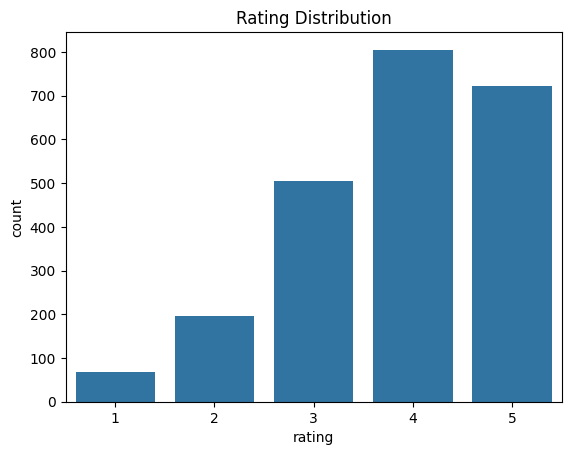

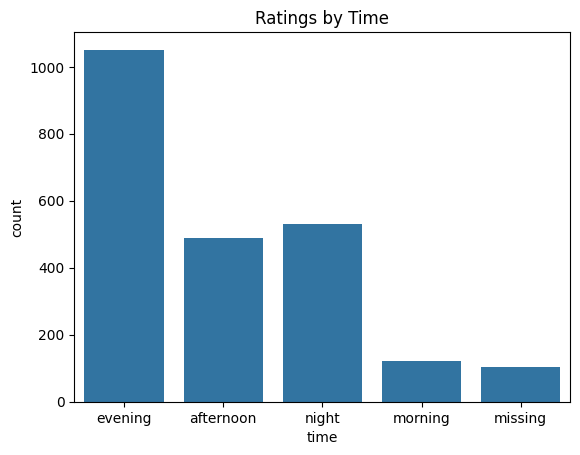

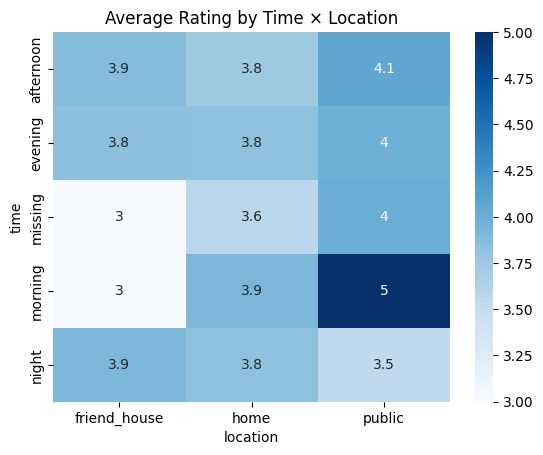

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Rating distribution
sns.countplot(data=df, x='rating')
plt.title("Rating Distribution")
plt.show()

# Ratings per context
sns.countplot(data=df, x='time')
plt.title("Ratings by Time")
plt.show()

# Heatmap: time × location
pivot = df.pivot_table(values='rating', index='time', columns='location', aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='Blues')
plt.title("Average Rating by Time × Location")
plt.show()


### ✅ Cell 6: Contextual Filtering + Train SVD



In [ ]:
from surprise.model_selection import train_test_split

# Filtered data for a specific context (e.g., 'evening')
selected_context = 'evening'
df_context = df[df['time'] == selected_context]

reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df_context[['userID', 'itemID', 'rating']], reader)

# Create a train-test split for Precision@5
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Train the SVD model
svd_model = SVD()
svd_model.fit(trainset)

# Evaluate RMSE/MAE with cross-validation
print(f"\n📊 SVD Results on context = '{selected_context.title()}':\n")
cross_validate(svd_model, data, measures=['RMSE', 'MAE'], cv=3, verbose=True)

# Predict on the actual test set for P@5
svd_predictions = svd_model.test(testset)
precision_svd = get_precision_at_k(svd_predictions, k=5)
print(f"🎯 SVD Precision@5: {precision_svd:.3f}")



📊 SVD Results on context = 'Evening':

Evaluating RMSE, MAE of algorithm SVD on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    1.0921  1.0276  1.0506  1.0568  0.0267  
MAE (testset)     0.8993  0.8311  0.8222  0.8509  0.0344  
Fit time          0.02    0.02    0.02    0.02    0.00    
Test time         0.00    0.00    0.00    0.00    0.00    
🎯 SVD Precision@5: 0.387


In [ ]:
from surprise import SVD, Dataset, Reader
from surprise.model_selection import cross_validate

# Unique valid time contexts (already mapped earlier)
contexts = df['time'].dropna().unique()

# Collect results
results = []

for context in contexts:
    df_context = df[df['time'] == context]
    n = df_context.shape[0]
    print(f"\n⏳ Context: {context} → {n} ratings")

    if n >= 5:
        reader = Reader(rating_scale=(1, 5))
        data = Dataset.load_from_df(df_context[['userID', 'itemID', 'rating']], reader)
        model = SVD()
        cv_result = cross_validate(model, data, measures=['RMSE', 'MAE'], cv=3, verbose=False)

        rmse_mean = cv_result['test_rmse'].mean()
        mae_mean = cv_result['test_mae'].mean()

        results.append({'Context': context, 'RMSE': rmse_mean, 'MAE': mae_mean})
    else:
        print("⚠️ Skipped: Not enough data")

# Display results
results_df = pd.DataFrame(results).sort_values(by='RMSE')
print("\n📊 SVD Performance by Time Context:")
display(results_df)



⏳ Context: evening → 1051 ratings

⏳ Context: afternoon → 489 ratings

⏳ Context: night → 531 ratings

⏳ Context: morning → 121 ratings

⏳ Context: missing → 104 ratings

📊 SVD Performance by Time Context:


,Context,RMSE,MAE
3,morning,0.947506,0.785780
1,afternoon,0.975351,0.772537
4,missing,1.016299,0.798748
2,night,1.019146,0.823870
0,evening,1.058116,0.854994


In [ ]:
from collections import defaultdict
import numpy as np

def get_precision_at_k(predictions, k=5, threshold=4.0):
    """
    Compute Precision@K for Surprise predictions
    """
    user_est_true = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = []
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)  # sort by predicted rating
        top_k = user_ratings[:k]
        num_relevant = sum((true_r >= threshold) for _, true_r in top_k)
        precisions.append(num_relevant / k)

    return np.mean(precisions)

# Test set predictions from Surprise SVD
svd_predictions = svd_model.test(testset)

# Compute Precision@5
precision_svd = get_precision_at_k(svd_predictions, k=5)
print(f"🎯 SVD Precision@5: {precision_svd:.3f}")


🎯 SVD Precision@5: 0.387


In [ ]:
!pip install tensorly


In [ ]:
import numpy as np
import tensorly as tl
from tensorly.decomposition import parafac
from sklearn.preprocessing import LabelEncoder

# Limit to top-N users and items (e.g., most active)
top_users = df['userID'].value_counts().head(20).index
top_items = df['itemID'].value_counts().head(20).index
valid_times = ['morning', 'afternoon', 'evening', 'night']

df_sample = df[
    df['userID'].isin(top_users) &
    df['itemID'].isin(top_items) &
    df['time'].isin(valid_times)
].copy()

# Re-encode for compact tensor
user_enc = LabelEncoder()
item_enc = LabelEncoder()
time_enc = LabelEncoder()

df_sample['user_idx'] = user_enc.fit_transform(df_sample['userID'])
df_sample['item_idx'] = item_enc.fit_transform(df_sample['itemID'])
df_sample['time_idx'] = time_enc.fit_transform(df_sample['time'])

# Initialize and fill tensor
tensor_shape = (
    df_sample['user_idx'].nunique(),
    df_sample['item_idx'].nunique(),
    df_sample['time_idx'].nunique()
)

tensor = np.full(tensor_shape, np.nan)

for row in df_sample.itertuples():
    tensor[row.user_idx, row.item_idx, row.time_idx] = row.rating

# Fill missing with mean
mean_rating = np.nanmean(tensor)
tensor = np.nan_to_num(tensor, nan=mean_rating)

# Convert to tensorly tensor
tl_tensor = tl.tensor(tensor)


In [ ]:
# Safe decomposition with low rank
rank = 3
factors = parafac(tl_tensor, rank=rank)

# Reconstruct and evaluate
reconstructed = tl.cp_to_tensor(factors)
rmse = np.sqrt(np.mean((tensor - reconstructed) ** 2))
print(f"📉 Subsampled Tensor RMSE: {rmse:.4f}")


📉 Subsampled Tensor RMSE: 0.2168


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack
import numpy as np

# Select relevant fields: user, item, and key contexts
df_fm = df[df['time'].isin(['morning', 'afternoon', 'evening', 'night'])].copy()

# Fill missing ratings if any
df_fm = df_fm[['userID', 'itemID', 'time', 'rating']].dropna()

# One-hot encode categorical features
encoder = OneHotEncoder()
# Preserve raw user/item/time before encoding
X_raw = df_fm[['userID', 'itemID', 'time']].copy()
X_cat = encoder.fit_transform(X_raw)
y = df_fm['rating'].values

# Train-test split
X_train, X_test, y_train, y_test, X_raw_train, X_raw_test = train_test_split(
    X_cat, y, X_raw, test_size=0.2, random_state=42
)

# Convert raw test to DataFrame
X_test_df = X_raw_test.reset_index(drop=True)

print(f"✅ Encoded feature matrix shape: {X_train.shape}")


✅ Encoded feature matrix shape: (1753, 1341)


In [ ]:
from fastFM import sgd
from sklearn.metrics import mean_squared_error

# Train FM regression model
fm = sgd.FMRegression(n_iter=1000, init_stdev=0.1, l2_reg=0.01, rank=8, random_state=42)
fm.fit(X_train, y_train)

# Predict
y_pred = fm.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"📉 Factorization Machine RMSE: {rmse:.4f}")


📉 Factorization Machine RMSE: 1.1182


In [ ]:
import numpy as np
import pandas as pd

def compute_precision_at_k_fm(X_test_df, y_true, y_pred, k=5, threshold=4.0):
    """
    Compute Precision@K for FM predictions.
    Requires a DataFrame (X_test_df) with 'userID' and 'itemID' columns to group predictions per user.
    """
    df_preds = pd.DataFrame({
        'userID': X_test_df['userID'].values,
        'itemID': X_test_df['itemID'].values,
        'true_rating': y_true,
        'predicted_rating': y_pred
    })

    precisions = []

    for user_id, group in df_preds.groupby('userID'):
        top_k = group.sort_values('predicted_rating', ascending=False).head(k)
        relevant = (top_k['true_rating'] >= threshold).sum()
        precisions.append(relevant / k)

    return np.mean(precisions)

# Example usage:
# X_test_df = pd.DataFrame(X_test_array, columns=['userID', 'itemID', ...])  # if needed
# Make sure X_test_df has 'userID' and 'itemID'

# Compute precision@5 for FM
precision_fm = compute_precision_at_k_fm(X_test_df, y_test, y_pred, k=5)
print(f"🎯 FM Precision@5: {precision_fm:.3f}")


🎯 FM Precision@5: 0.423


In [ ]:
def precision_at_k(y_true, y_pred, k=5):
    """Assumes y_true and y_pred are aligned and sorted by prediction."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    top_k = np.argsort(y_pred)[-k:][::-1]
    relevant = y_true[top_k] >= 4  # rating ≥ 4 considered relevant
    return np.sum(relevant) / k

# Apply to the sample_data
precision = precision_at_k(sample_data['rating'].values, predictions.flatten(), k=5)
print(f"🎯 Precision@5: {precision:.3f}")


🎯 Precision@5: 0.400


In [ ]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

# 2. DATA LOADING
from google.colab import drive
drive.mount('/content/drive')

# Adjusted path
base_path = '/content/drive/My Drive/CoMoDa/'

# Load Excel and CSV files accordingly
ratings_context = pd.read_excel(base_path + 'LDOS-CoMoDa.xls')
titles = pd.read_csv(base_path + 'itemsTitles.csv', sep=';', names=['item_id', 'title'], engine='python', on_bad_lines='skip')
item_metadata = pd.read_csv(base_path + 'itemMetadataDecoded.csv', sep=';', engine='python', on_bad_lines='skip')



# 3. DATA CLEANING
titles['item_id'] = pd.to_numeric(titles['item_id'], errors='coerce')
titles.dropna(subset=['item_id'], inplace=True)
titles['item_id'] = titles['item_id'].astype(int)

item_metadata['item_ID'] = pd.to_numeric(item_metadata['item_ID'], errors='coerce')
item_metadata.dropna(subset=['item_ID'], inplace=True)
item_metadata['item_ID'] = item_metadata['item_ID'].astype(int)

# 4. DATA MERGING
ratings_titles = ratings_context.merge(titles, left_on='itemID', right_on='item_id', how='left')
ratings_full = ratings_titles.merge(item_metadata, left_on='itemID', right_on='item_ID', how='left')
ratings_full.drop(columns=['item_id', 'item_ID', 'row_ID'], inplace=True, errors='ignore')

# 5. FEATURE ENCODING
categorical_cols = [
    'userID', 'itemID', 'Genre1', 'Genre2', 'Genre3',
    'Director', 'Actor1', 'Actor2', 'Actor3',
    'time', 'daytype', 'season', 'location', 'mood', 'social'
]

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    ratings_full[col] = le.fit_transform(ratings_full[col].astype(str))
    encoders[col] = le

# 6. SPLIT DATA
train_data, test_data = train_test_split(ratings_full, test_size=0.2, random_state=42)

# 6a. OVERSAMPLING LOW RATINGS
low_ratings = train_data[train_data['rating'] <= 2]
oversample = pd.concat([low_ratings] * 5, ignore_index=True)
train_data = pd.concat([train_data, oversample], ignore_index=True)

# 7. FIND MAXIMUMS FOR EMBEDDINGS
genre_max = max(train_data['Genre1'].max(), train_data['Genre2'].max(), train_data['Genre3'].max())
actor_max = max(train_data['Actor1'].max(), train_data['Actor2'].max(), train_data['Actor3'].max())

# 8. MODEL BUILDING
# -- a) Neural CF Model --
user_emb_in = layers.Input(shape=(1,), name='user_cf')
item_emb_in = layers.Input(shape=(1,), name='item_cf')
user_embedding = layers.Embedding(input_dim=ratings_full['userID'].nunique()+1, output_dim=32)(user_emb_in)
item_embedding = layers.Embedding(input_dim=ratings_full['itemID'].nunique()+1, output_dim=32)(item_emb_in)
user_vec = layers.Flatten()(user_embedding)
item_vec = layers.Flatten()(item_embedding)
cf_concat = layers.Concatenate()([user_vec, item_vec])
cf_dense = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))(cf_concat)
cf_output = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001))(cf_dense)
cf_model = Model(inputs=[user_emb_in, item_emb_in], outputs=cf_output)

# -- b) Deep Content-Based Model --
genre_emb_in = layers.Input(shape=(3,), name='genre_cb')
actor_emb_in = layers.Input(shape=(3,), name='actor_cb')
genre_emb = layers.Embedding(input_dim=genre_max+1, output_dim=8)(genre_emb_in)
actor_emb = layers.Embedding(input_dim=actor_max+1, output_dim=8)(actor_emb_in)

attention_genre = layers.Attention()([genre_emb, genre_emb])
attention_actor = layers.Attention()([actor_emb, actor_emb])

genre_vec = layers.Flatten()(attention_genre)
actor_vec = layers.Flatten()(attention_actor)
cbf_concat = layers.Concatenate()([genre_vec, actor_vec])
cbf_dense = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))(cbf_concat)
cbf_output = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001))(cbf_dense)
cbf_model = Model(inputs=[genre_emb_in, actor_emb_in], outputs=cbf_output)

# -- c) Context-Aware Model --
context_input = layers.Input(shape=(6,), name='context_input')
context_dense = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(context_input)
context_output = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001))(context_dense)
context_model = Model(inputs=context_input, outputs=context_output)

# -- d) Fusion Meta-Learner --
user_in = layers.Input(shape=(1,), name='user_in')
item_in = layers.Input(shape=(1,), name='item_in')
genre_in = layers.Input(shape=(3,), name='genre_in')
actor_in = layers.Input(shape=(3,), name='actor_in')
context_in = layers.Input(shape=(6,), name='context_in')

cf_branch = cf_model([user_in, item_in])
cbf_branch = cbf_model([genre_in, actor_in])
context_branch = context_model(context_in)

fusion = layers.Concatenate()([cf_branch, cbf_branch, context_branch])
fusion_dense = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(fusion)
fusion_dense = layers.Dropout(0.3)(fusion_dense)
fusion_dense2 = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))(fusion_dense)
# Bias correction applied after final dense layer
raw_output = layers.Dense(1, activation='linear')(fusion_dense2)
bias = layers.Dense(1, activation='linear', use_bias=True)(fusion_dense2)
final_output = raw_output + bias

hybrid_model = Model(inputs=[user_in, item_in, genre_in, actor_in, context_in], outputs=final_output)

# 9. COMPILE MODEL
hybrid_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='mae', metrics=['mae'])

# 10. TRAINING
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = hybrid_model.fit(
    x=[train_data['userID'], train_data['itemID'], train_data[['Genre1', 'Genre2', 'Genre3']], train_data[['Actor1', 'Actor2', 'Actor3']], train_data[['time', 'daytype', 'season', 'location', 'mood', 'social']]],
    y=train_data['rating'],
    validation_split=0.1,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping]
)

# 11. EVALUATION
results = hybrid_model.evaluate(
    x=[test_data['userID'], test_data['itemID'], test_data[['Genre1', 'Genre2', 'Genre3']], test_data[['Actor1', 'Actor2', 'Actor3']], test_data[['time', 'daytype', 'season', 'location', 'mood', 'social']]],
    y=test_data['rating']
)
print("Test Loss (MSE):", results[0])
print("Test MAE:", results[1])

# 12. SAVE MODEL
hybrid_model.save('hybrid_recommender_model.h5')

# 13. PREDICTION AND FULL SAMPLE EVALUATION

# Pick 20 random test samples
sample_data = test_data.sample(20, random_state=42)

# Predict ratings
predictions = hybrid_model.predict([
    sample_data['userID'],
    sample_data['itemID'],
    sample_data[['Genre1', 'Genre2', 'Genre3']],
    sample_data[['Actor1', 'Actor2', 'Actor3']],
    sample_data[['time', 'daytype', 'season', 'location', 'mood', 'social']]
])
predictions = np.clip(predictions, 1, 5)  # Clip predictions between 1 and 5

# Combine into a DataFrame for easy view
pred_results = pd.DataFrame({
    'Predicted_Rating': predictions.flatten(),
    'Actual_Rating': sample_data['rating'].values
})

# Print neatly
print("Sample Predictions vs Actual Ratings:")
print(pred_results)

# Calculate RMSE on sample
from sklearn.metrics import mean_squared_error

rmse_sample = np.sqrt(mean_squared_error(pred_results['Actual_Rating'], pred_results['Predicted_Rating']))
print(f"Sample RMSE: {rmse_sample:.3f}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 1/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 3.2268 - mae: 2.6191 - val_loss: 1.8290 - val_mae: 1.2581
Epoch 2/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8507 - mae: 1.2916 - val_loss: 1.9100 - val_mae: 1.3845
Epoch 3/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7234 - mae: 1.2079 - val_loss: 1.7744 - val_mae: 1.2869
Epoch 4/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.6512 - mae: 1.1719 - val_loss: 1.7922 - val_mae: 1.3354
Epoch 5/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.4922 - mae: 1.0417 - val_loss: 1.3802 - val_mae: 0.9464
Epoch 6/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2748 - mae: 0.8457 - val_loss: 1.1001 - val_mae: 0.6852
Epoch 7/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0744 - mae: 0.6643 - val_loss: 0.8605 - val_mae: 0.4639
Epoch 8/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/st

Test Loss (MSE): 1.033450961112976
Test MAE: 0.9224773049354553
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
Sample Predictions vs Actual Ratings:
    Predicted_Rating  Actual_Rating
0           3.889732              4
1           3.623209              4
2           3.824740              5
3           3.371840              4
4           3.799203              4
5           3.081678              4
6           3.683740              4
7           3.613136              1
8           4.430821              3
9           3.465584              4
10          3.994267              4
11          4.376445              4
12          4.667588              4
13          4.360684              3
14          3.421378              3
15          3.270644              3
16          3.692672              5
17          3.861672              4
18          4.608582              3
19          1.777279              5
Sample RMSE: 1.214


In [1]:
!pip install ipywidgets
from IPython.display import display
!pip install gradio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.1/54.1 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.9/322.9 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 113.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 5.9 MB/s eta 0:00:00


In [5]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Path to your dataset (adjust if needed)
base_path = '/content/drive/My Drive/CoMoDa/'

# Load the ratings data from Excel file
ratings = pd.read_excel(base_path + 'LDOS-CoMoDa.xls')


Mounted at /content/drive


In [6]:
# Ensure 'ratings' is already loaded correctly before this
# Drop rows with missing essential context or rating information
ratings = ratings.dropna(subset=['rating', 'time', 'location', 'social', 'itemID'])

# Convert to appropriate types if needed
ratings['itemID'] = ratings['itemID'].astype(int)
ratings['rating'] = ratings['rating'].astype(float)

# Optional: Filter out rare context values (if needed for stability)
min_ratings_per_context = 2
context_counts = ratings.groupby(['time', 'location', 'social']).size().reset_index(name='count')
valid_contexts = context_counts[context_counts['count'] >= min_ratings_per_context]
ratings = ratings.merge(valid_contexts.drop('count', axis=1), on=['time', 'location', 'social'])

# Final assignment
df = ratings.copy()


In [ ]:
import gradio as gr

# Ensure this is your filtered and cleaned ratings dataframe
df = ratings.copy()

def gradio_recommender(time_context, location_context, social_context):
    fallback_level = "✅ Full match"

    context_df = df[
        (df['time'] == time_context) &
        (df['location'] == location_context) &
        (df['social'] == social_context)
    ]

    if context_df.empty:
        fallback_level = "ℹ️ Used fallback: time + location"
        context_df = df[
            (df['time'] == time_context) &
            (df['location'] == location_context)
        ]

    if context_df.empty:
        fallback_level = "⚠️ Used fallback: time only"
        context_df = df[df['time'] == time_context]

    if context_df.empty:
        fallback_level = "⚠️ Used fallback: full dataset"
        context_df = df.copy()

    movie_stats = context_df.groupby('itemID').agg(
        avg_rating=('rating', 'mean'),
        count=('rating', 'count')
    ).reset_index()

    if len(movie_stats[movie_stats['count'] >= 2]) >= 5:
        movie_stats = movie_stats[movie_stats['count'] >= 2]
    elif len(movie_stats) < 5:
        movie_stats = df.groupby('itemID').agg(avg_rating=('rating', 'mean')).reset_index()
        fallback_level += "\n⚠️ Too sparse — defaulting to global top movies"

    top_movies = movie_stats.sort_values(by='avg_rating', ascending=False).head(5)
    recommendations = [f"{row['itemID']} (Rating: {row['avg_rating']:.2f})" for _, row in top_movies.iterrows()]

    return "\n".join(recommendations), fallback_level

time_dd = list(df['time'].dropna().unique())
location_dd = list(df['location'].dropna().unique())
social_dd = list(df['social'].dropna().unique())

with gr.Blocks() as demo:
    gr.Markdown("### 🎬 Cinematrix: Context-Aware Movie Recommender")
    with gr.Row():
        time_input = gr.Dropdown(time_dd, label="Select Time Context")
        location_input = gr.Dropdown(location_dd, label="Select Location Context")
        social_input = gr.Dropdown(social_dd, label="Select Social Context")
    with gr.Row():
        output_recommendations = gr.Textbox(label="🎯 Top Movie Recommendations")
        output_info = gr.Textbox(label="ℹ️ Contextual Info")

    submit_button = gr.Button("Get Recommendations")
    submit_button.click(fn=gradio_recommender,
                        inputs=[time_input, location_input, social_input],
                        outputs=[output_recommendations, output_info])

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4c3e10d25d09b9fae1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
